In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")
import joblib


In [2]:
df = pd.read_csv(r"C:\Users\Mahadev\Downloads\archive\Crop_recommendation-checkpoint.csv")

df.head()
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())
print("\nClass Count:")
print(df['label'].value_counts())



Dataset Shape: (2200, 8)

Columns: Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Class Count:
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pom

In [3]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df = df.drop_duplicates()
print("\nShape After Removing Duplicates:", df.shape)


Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicates: 0

Shape After Removing Duplicates: (2200, 8)


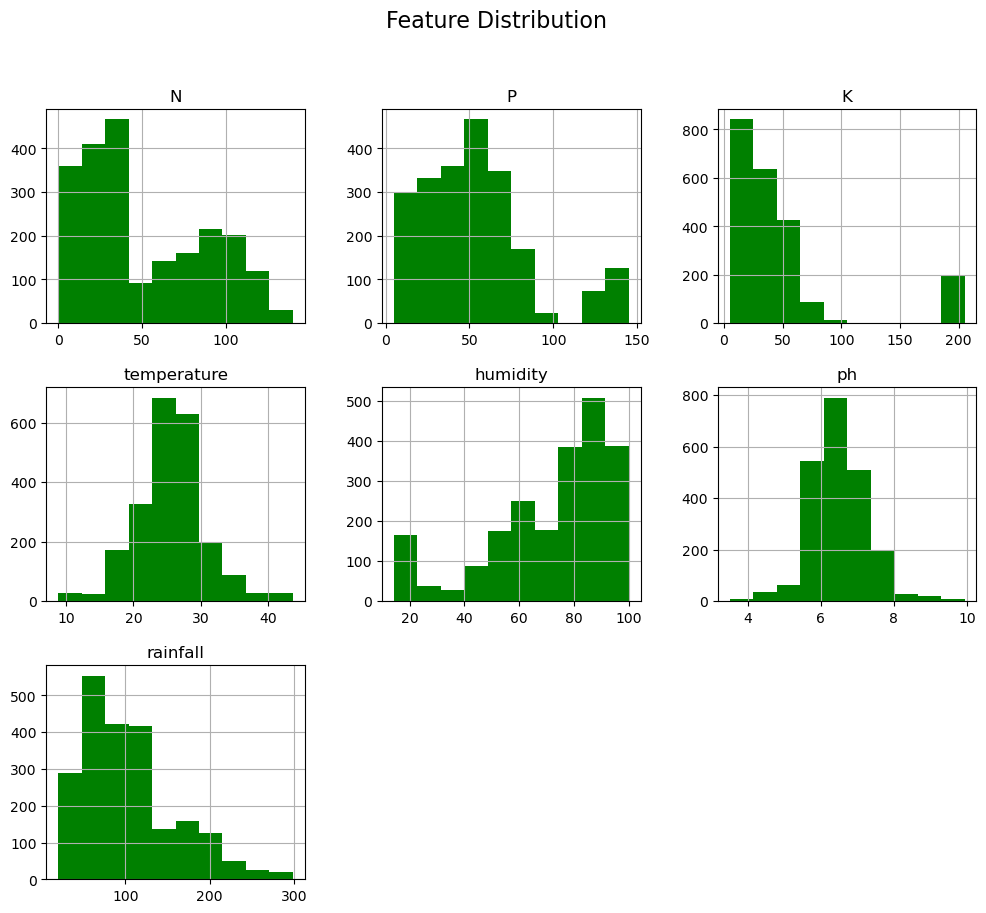

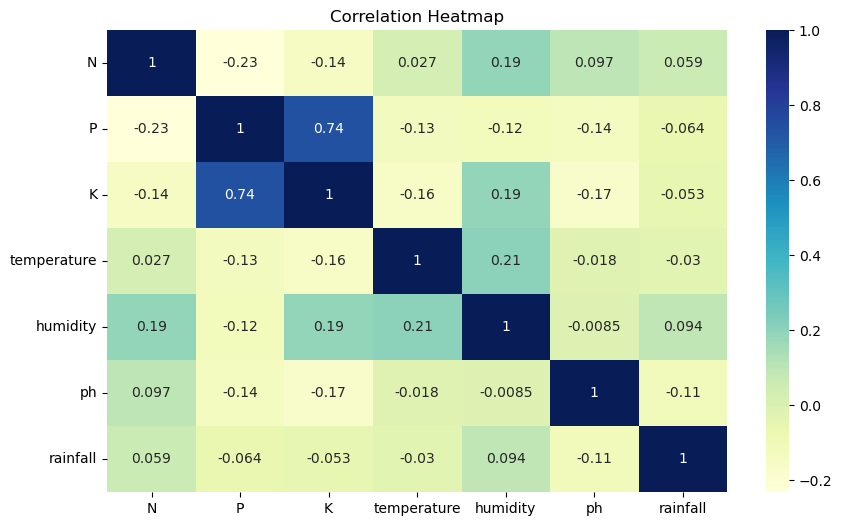

In [4]:

df.hist(figsize=(12,10), color="green")
plt.suptitle("Feature Distribution", fontsize=16)
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()



In [5]:
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (1760, 7)
Test Shape: (440, 7)


In [6]:
models = {
    "RandomForest": RandomForestClassifier(),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    cv = cross_val_score(model, X, y, cv=5).mean()
    
    results[name] = [acc, cv]

results_df = pd.DataFrame(results, index=["Test Accuracy", "Cross Val Score"])
results_df


,RandomForest,NaiveBayes,SVM,DecisionTree,KNN
Test Accuracy,0.993182,0.995455,0.961364,0.981818,0.970455
Cross Val Score,0.992727,0.995000,0.978182,0.987273,0.979545


Best Model: NaiveBayes

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00

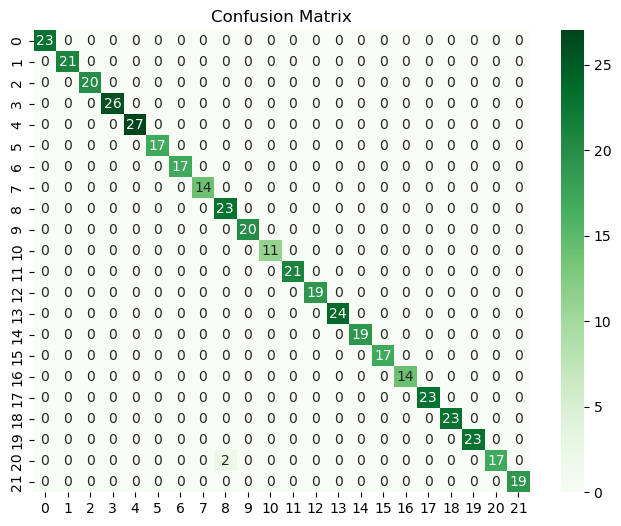

In [7]:
best_model_name = max(results, key=lambda k: results[k][0])
print("Best Model:", best_model_name)

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Greens", fmt='d')
plt.title("Confusion Matrix")
plt.show()


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "RandomForest": RandomForestClassifier(),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results[name] = acc
    trained_models[name] = model

print("Model Accuracies:", results)

best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model is:", best_model_name)
print("Accuracy:", results[best_model_name])


Model Accuracies: {'RandomForest': 0.9931818181818182, 'NaiveBayes': 0.9954545454545455, 'SVM': 0.9613636363636363, 'DecisionTree': 0.9863636363636363, 'KNN': 0.9704545454545455}
Best Model is: NaiveBayes
Accuracy: 0.9954545454545455


In [9]:
joblib.dump(best_model, "crop_model.pkl")
joblib.dump(le, "label_encoder.pkl")
print("Model Saved Successfully")


Model Saved Successfully
